In [1]:
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore

In [10]:
df = pd.read_excel("E:\IUT\Lessons\Project-Bachelor\Husbandry\Dataset\TCI_sas (1).xlsx", sheet_name="Sheet1", usecols = ["firstmilk","firstmilkdays",
                                                                       "prelendays","drylendays","milkdays",
                                                                       "grp","curent_Milk305","previous_Milk305",
                                                                       "firstmilk_previous","SCS_305"])


In [11]:
df.head()

,firstmilk,firstmilkdays,prelendays,drylendays,milkdays,grp,curent_Milk305,previous_Milk305,firstmilk_previous,SCS_305
0,53.6,19,284,48.0,381.0,20,14469,15930,52.223434,2.305667
1,21.2,7,279,33.0,342.0,22,11348,13558,35.899478,4.743529
2,21.8,19,275,138.0,309.0,21,9137,9055,36.528684,3.437178
3,36.0,29,270,31.0,314.0,21,10679,11419,43.183183,5.538713
4,27.4,28,272,146.0,499.0,19,8921,13735,50.525626,5.290468


In [12]:
df.isnull().sum()

firstmilk                0
firstmilkdays            0
prelendays               0
drylendays            2059
milkdays              2059
grp                      0
curent_Milk305           0
previous_Milk305         0
firstmilk_previous       0
SCS_305                  0
dtype: int64

In [8]:
df['drylendays'].fillna(df['drylendays'].median(), inplace=True)
df['milkdays'].fillna(df['milkdays'].median(), inplace=True)

C:\Users\sepri\AppData\Local\Temp\ipykernel_19412\3106129121.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['drylendays'].fillna(df['drylendays'].median(), inplace=True)
C:\Users\sepri\AppData\Local\Temp\ipykernel_19412\3106129121.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [5]:
df['drylendays'].fillna(df['drylendays'].mean(), inplace=True)
df['milkdays'].fillna(df['milkdays'].mean(), inplace=True)

C:\Users\sepri\AppData\Local\Temp\ipykernel_14948\3423088202.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['drylendays'].fillna(df['drylendays'].mean(), inplace=True)
C:\Users\sepri\AppData\Local\Temp\ipykernel_14948\3423088202.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [9]:
df.isnull().sum()

firstmilk             0
firstmilkdays         0
prelendays            0
drylendays            0
milkdays              0
grp                   0
curent_Milk305        0
previous_Milk305      0
firstmilk_previous    0
SCS_305               0
dtype: int64

<Figure size 2000x1500 with 0 Axes>

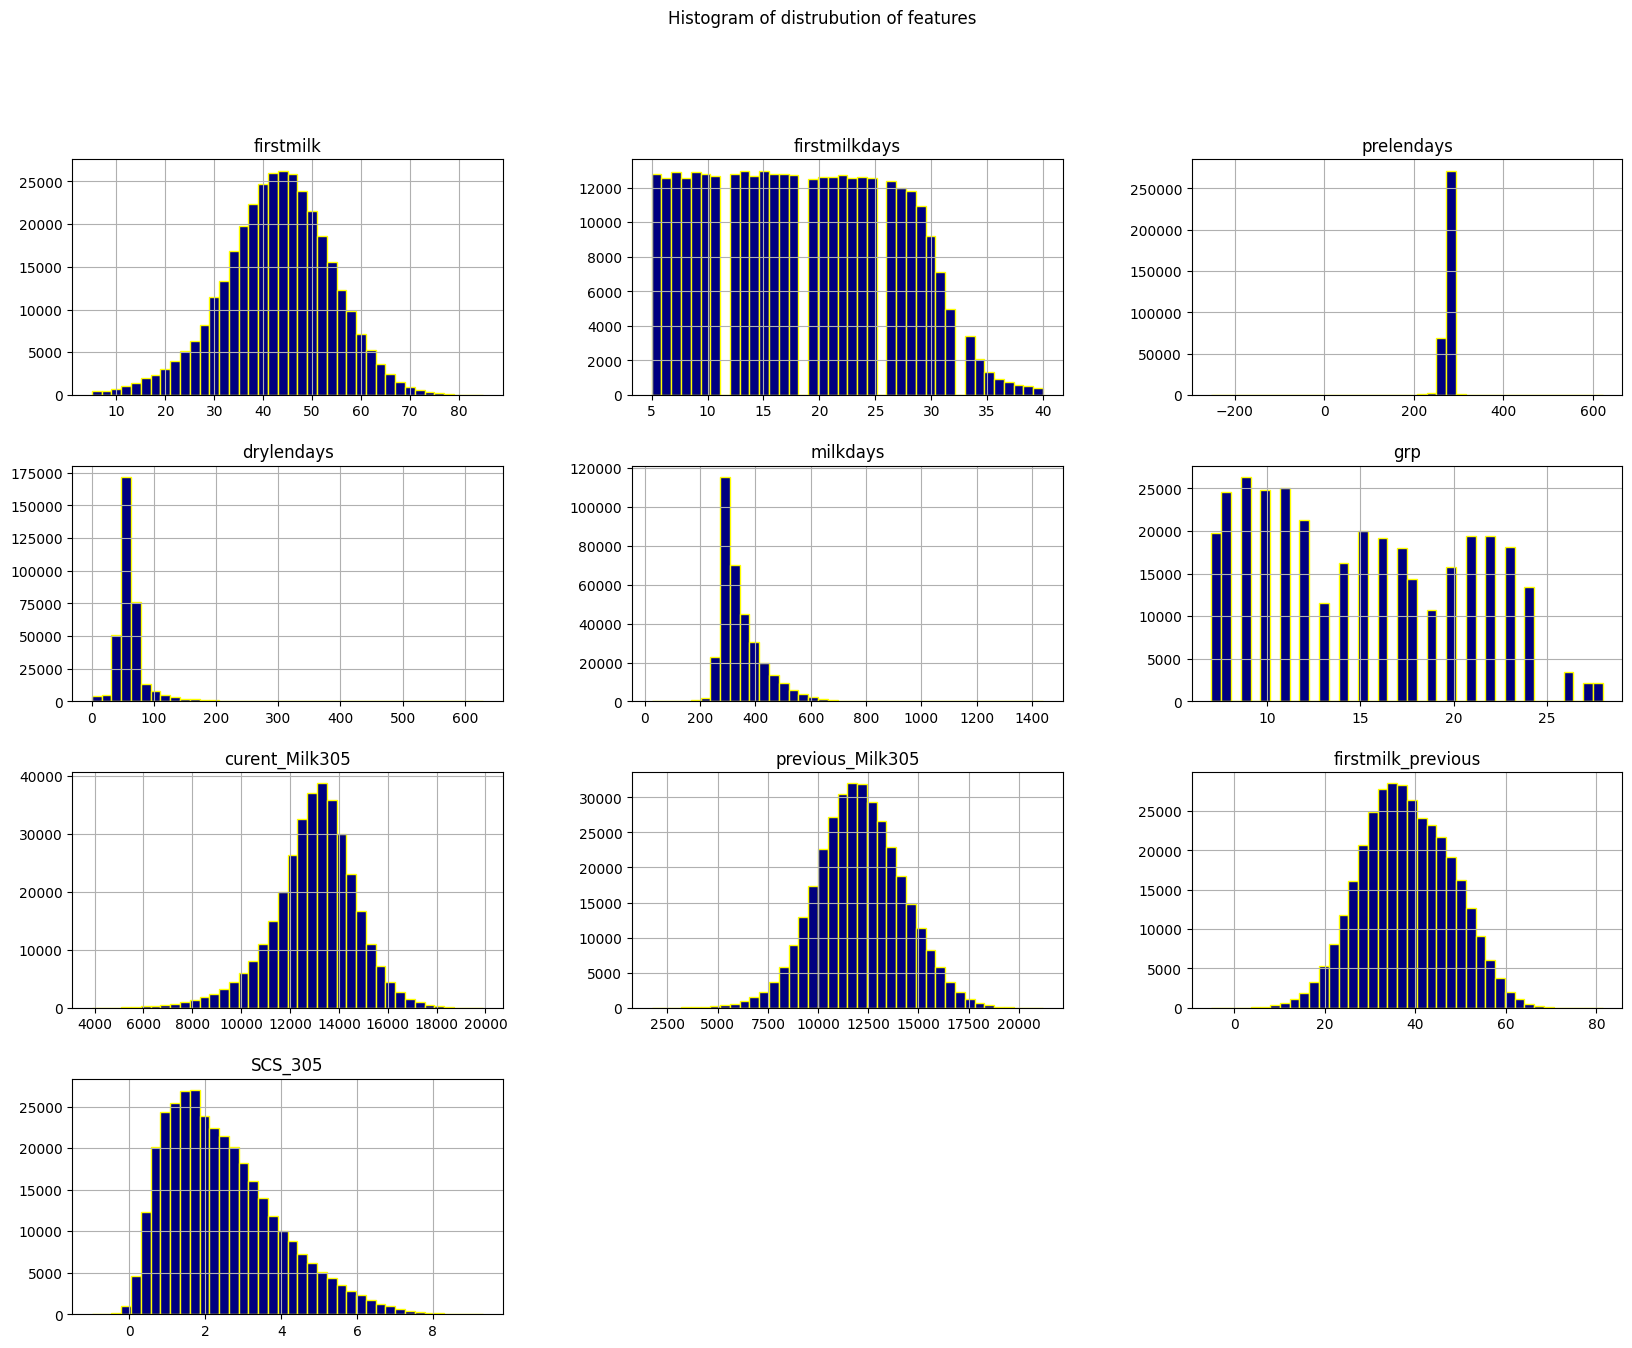

In [13]:
plt.figure(figsize=(20,15))
df.hist(bins=40,figsize=(20,15),color='navy',edgecolor='yellow')
plt.suptitle('Histogram of distrubution of features')
plt.show()

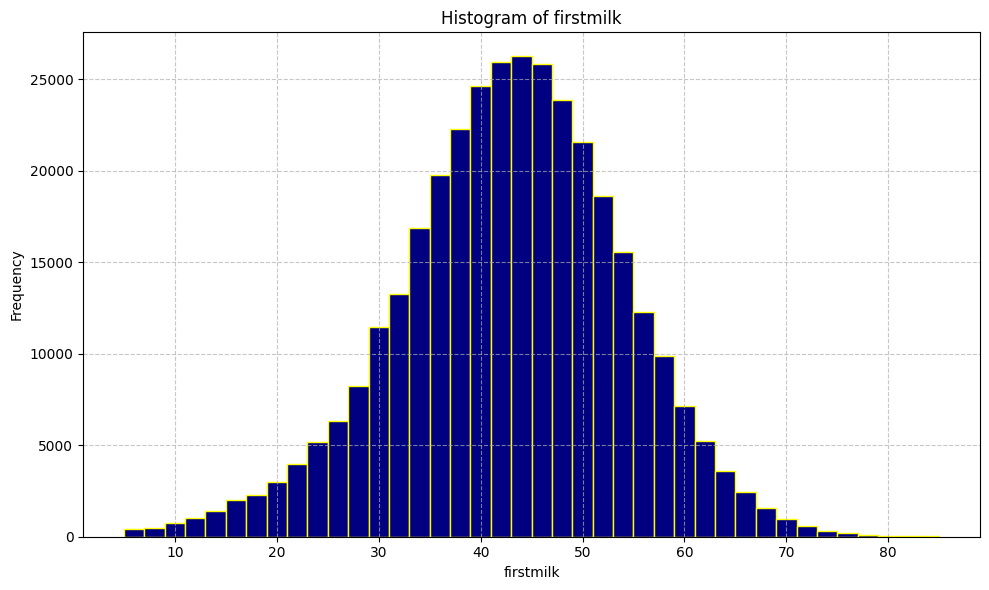

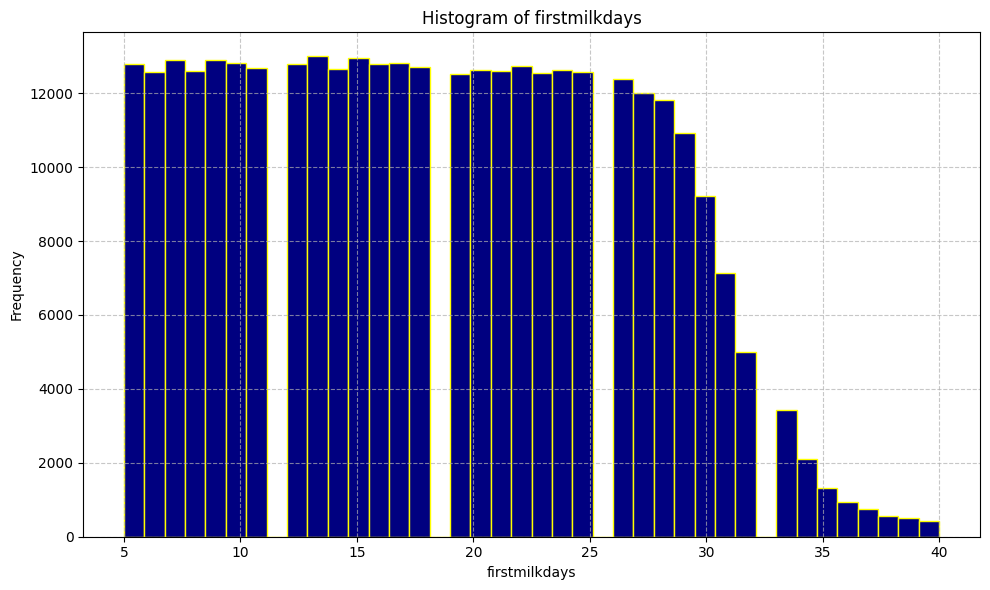

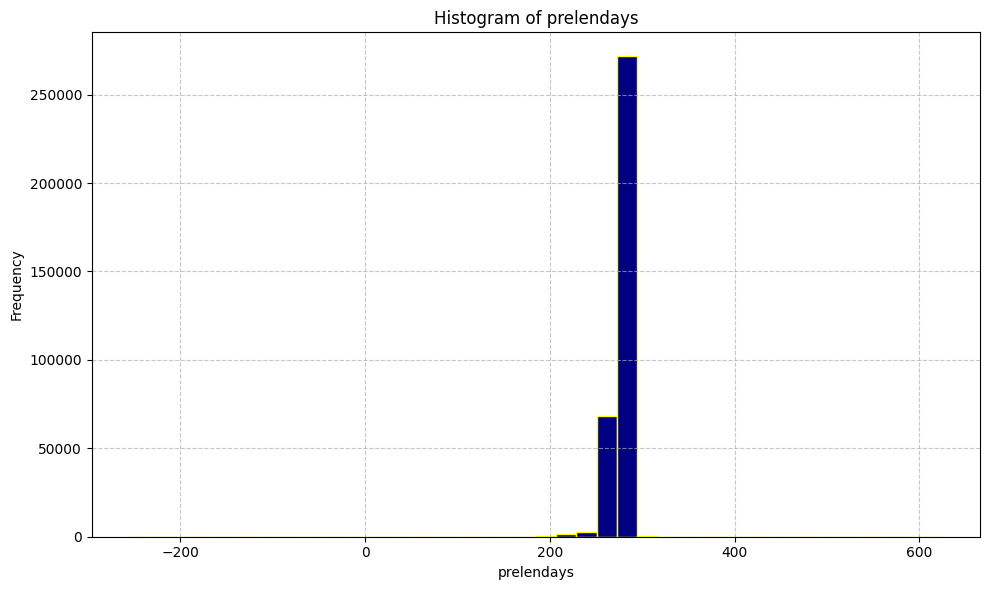

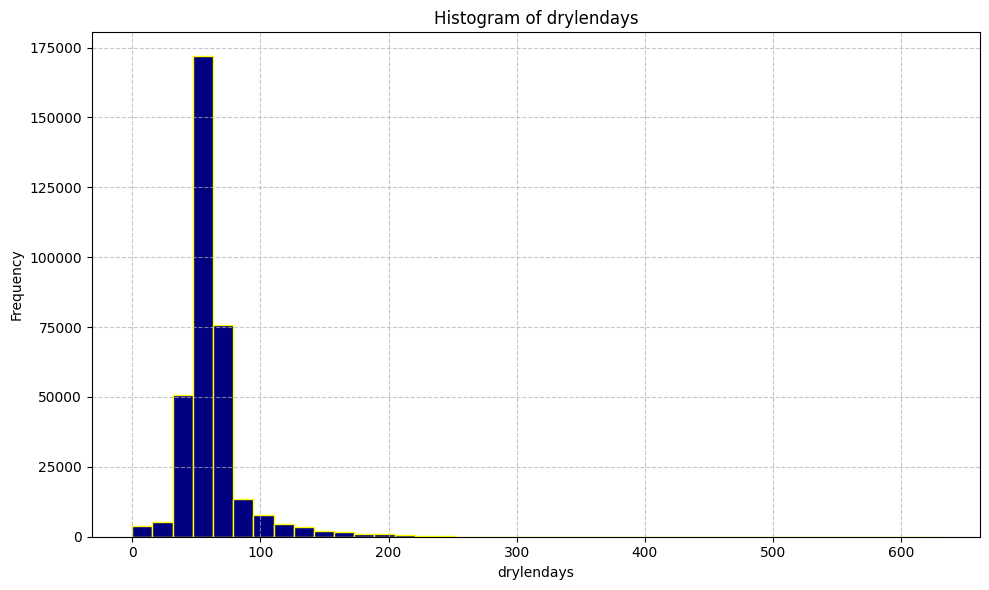

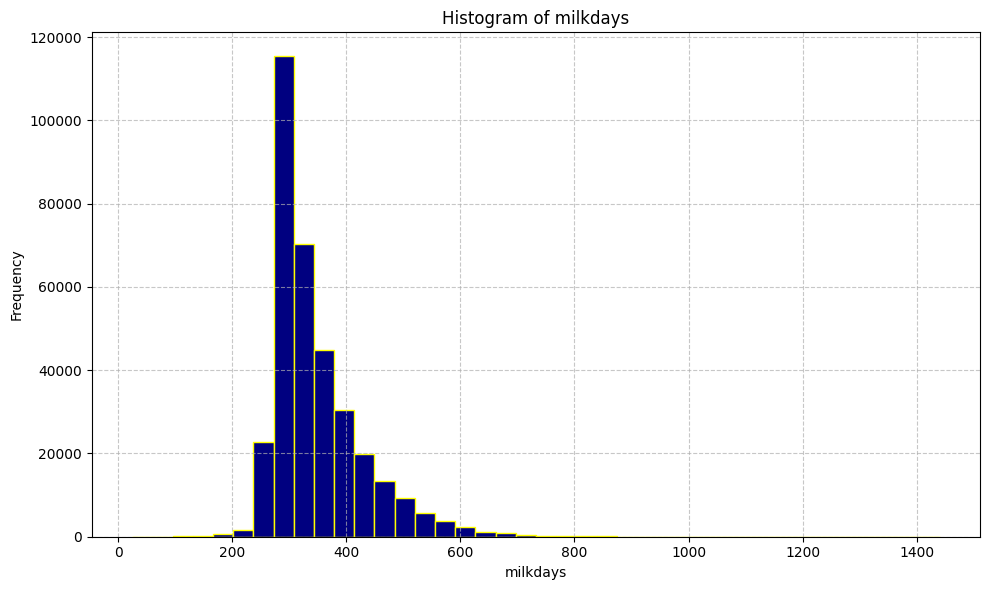

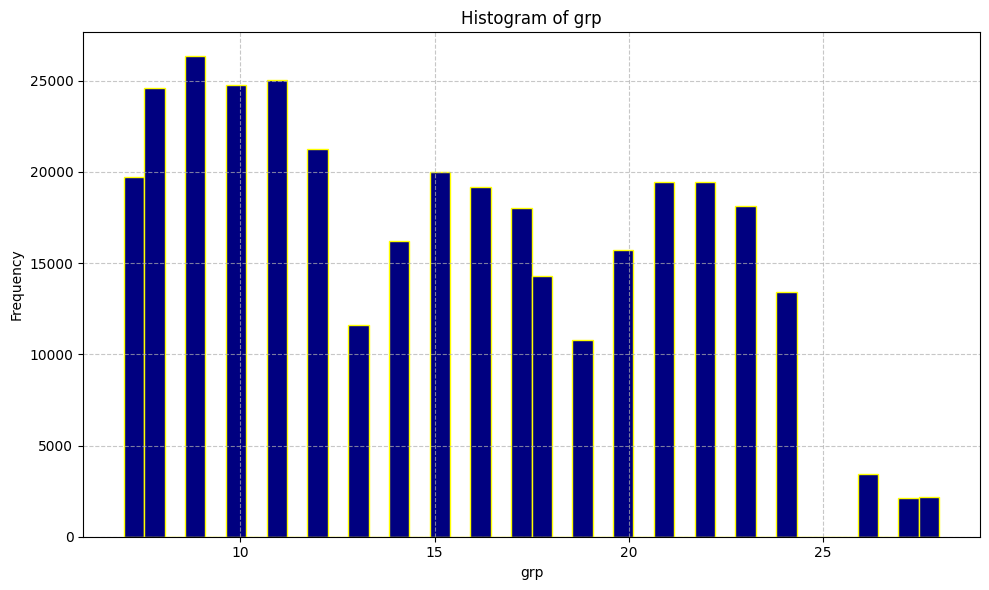

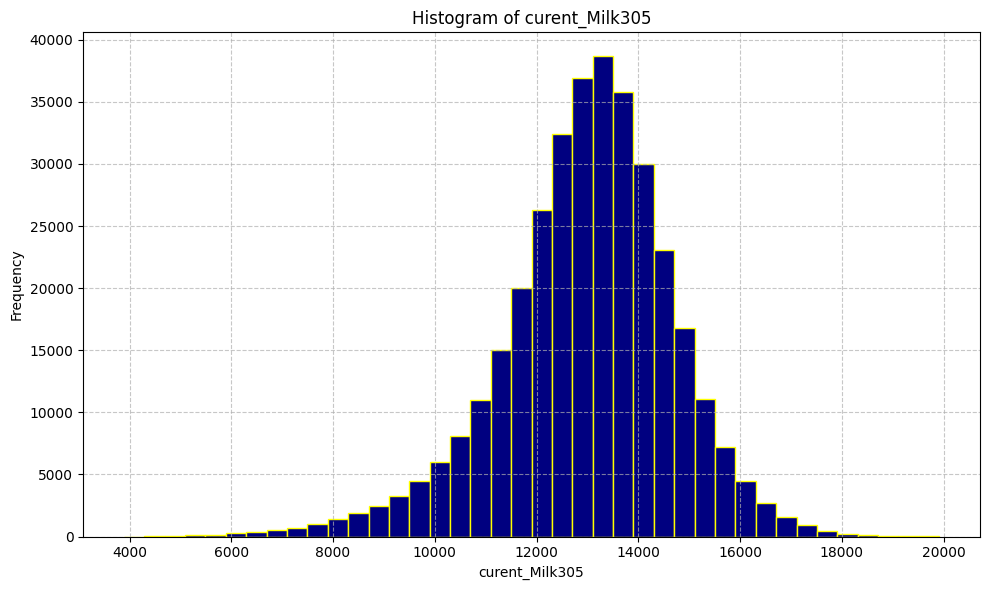

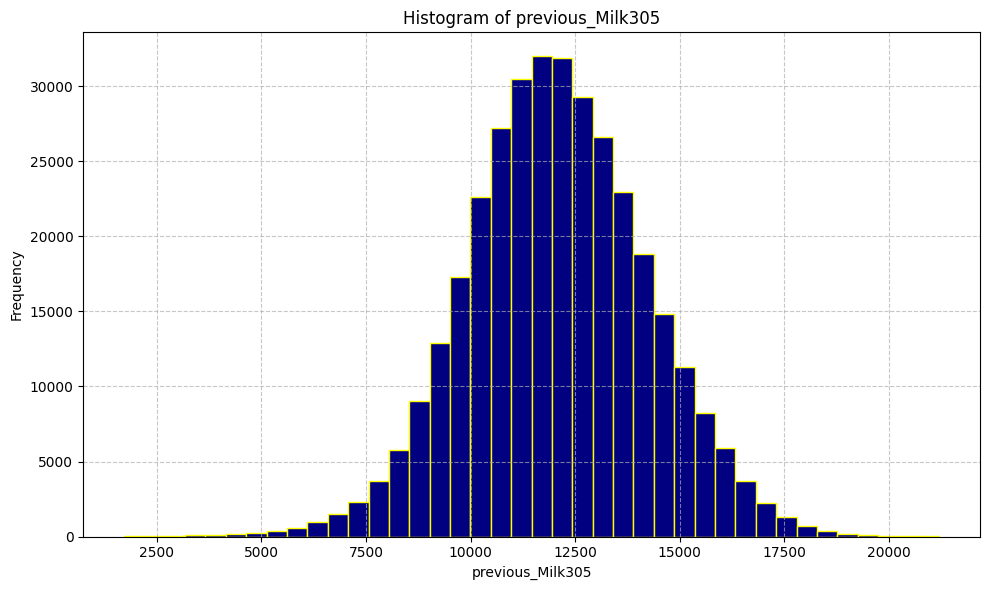

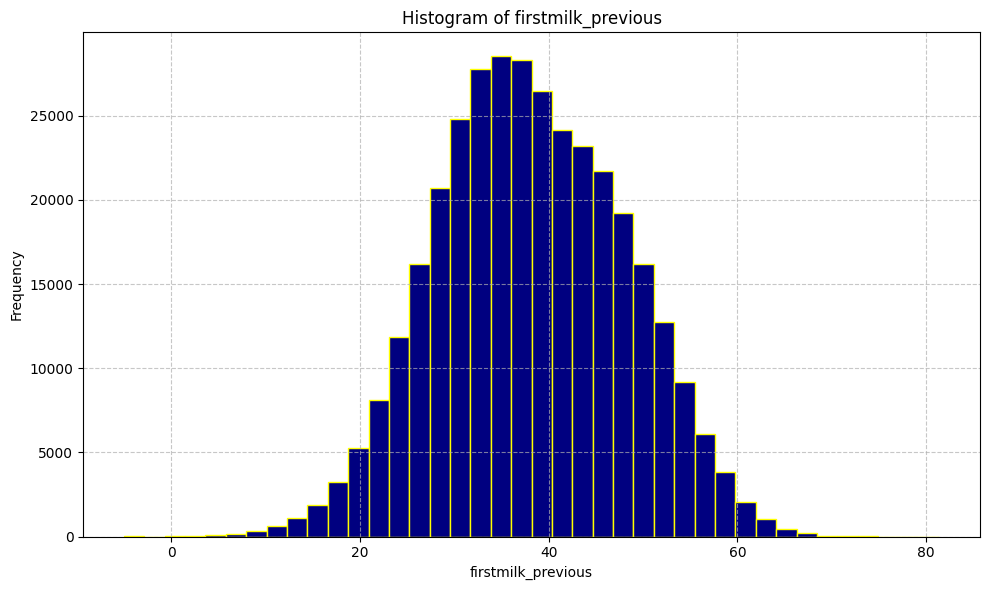

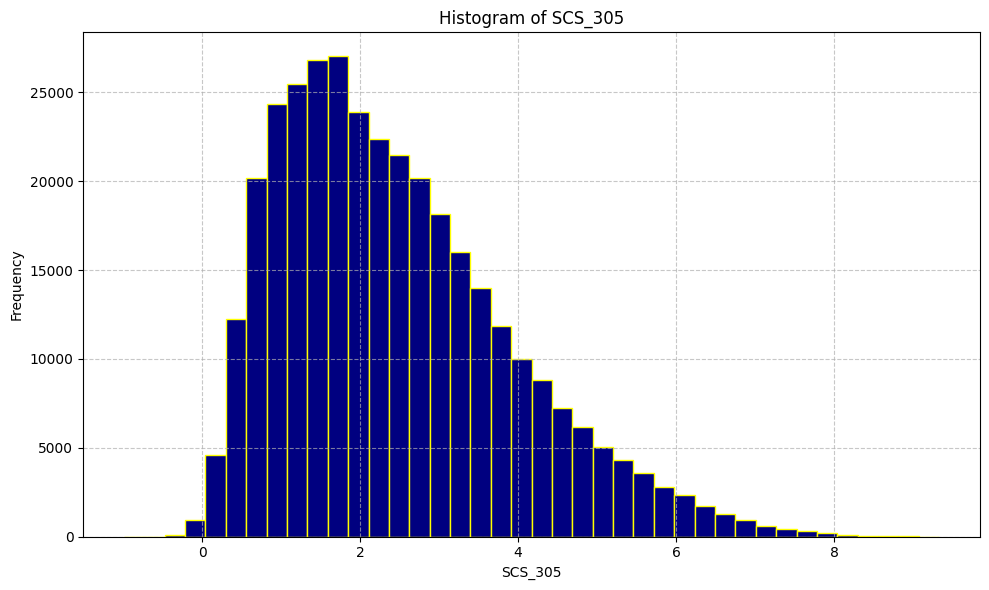

In [5]:
# لیست ستون‌ها برای رسم هیستوگرام
columns_to_plot = ["firstmilk", "firstmilkdays", "prelendays", "drylendays", "milkdays",
                   "grp", "curent_Milk305", "previous_Milk305", "firstmilk_previous", "SCS_305"]

# رسم هیستوگرام برای هر متغیر به‌صورت جداگانه
for column in columns_to_plot:
    plt.figure(figsize=(10, 6))  # اندازه هر نمودار
    df[column].hist(bins=40, color='navy', edgecolor='yellow')  # رنگ و لبه‌ها مشابه کد قبلی
    plt.title(f'Histogram of {column}')  # عنوان هر نمودار
    plt.xlabel(column)  # برچسب محور x
    plt.ylabel('Frequency')  # برچسب محور y
    plt.grid(True, linestyle='--', alpha=0.7)  # اضافه کردن شبکه برای خوانایی بهتر
    plt.tight_layout()  # تنظیم خودکار فاصله‌ها
    plt.show()

<Axes: >

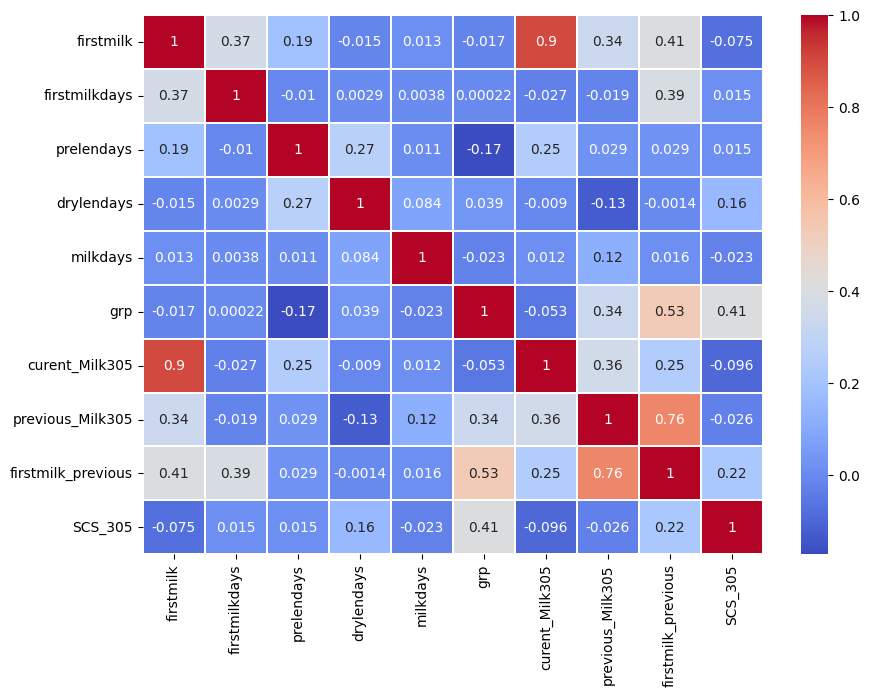

In [14]:
correlation = df.corr()

fig, ax = plt.subplots(figsize=(10, 7))  
sns.heatmap(correlation, ax=ax, cmap='coolwarm', annot=True, linewidths=0.30)

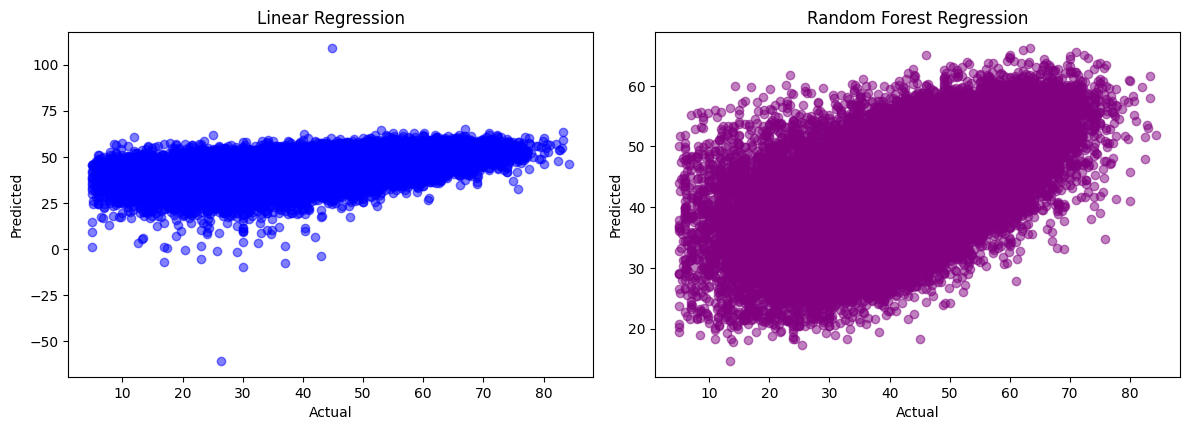

Linear Regression - MSE: 84.45608880636145 R2: 0.31090611763252096
Random Forest - MSE: 81.04657672768866 R2: 0.338724999000071


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


df = df.dropna()

df = df.drop(columns={'curent_Milk305'})

X = df.drop('firstmilk', axis=1)
y = df['firstmilk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

# Random Forest Regressor Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.5)
plt.title('Linear Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(2, 2, 2)
plt.scatter(y_test, y_pred_rf, color='purple', alpha=0.5)
plt.title('Random Forest Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

print("Linear Regression - MSE:", lr_mse, "R2:", lr_r2)
print("Random Forest - MSE:", rf_mse, "R2:", rf_r2)

# feature selection

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


X = df.drop(columns=["firstmilk", "curent_Milk305"])
y = df["firstmilk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": importances}).sort_values(by="Importance", ascending=False)
print(feature_importance)

              Feature  Importance
5    previous_Milk305    0.215179
0       firstmilkdays    0.183556
6  firstmilk_previous    0.131970
1          prelendays    0.109244
7             SCS_305    0.107848
3            milkdays    0.103798
2          drylendays    0.090751
4                 grp    0.057652


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# (Threshold = 0.1)
important_features = ["previous_Milk305","firstmilkdays","firstmilk_previous","prelendays","SCS_305","milkdays"]

X_important = df[important_features]
y = df["firstmilk"]

X_train, X_test, y_train, y_test = train_test_split(X_important, y, test_size=0.2, random_state=42)

rf_model_important = RandomForestRegressor(random_state=42)
rf_model_important.fit(X_train, y_train)

y_pred = rf_model_important.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Squared Error (MSE): 84.29285161655369
Root Mean Squared Error (RMSE): 9.181113854895477


# feature selection techniques

## 1- Percent Missing Value

In [10]:
missing_percentage = df.isnull().mean() * 100

threshold = 50
df = df.loc[:, missing_percentage <= threshold]


## 2- Amount of Variation

In [11]:
variances = df.var()

variance_threshold = 0.01
df = df.loc[:, variances > variance_threshold]


## 3- Pairwise Correlation

In [12]:
correlation_matrix = df.corr().abs()

# قطر
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_corr_columns = [
    column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)
]

df = df.drop(columns=high_corr_columns)


# cluster and correlation with the target

In [19]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

X = df.drop('firstmilk', axis=1)
y = df['firstmilk']

correlation_matrix = X.corr().abs()

distance_matrix = 1 - correlation_matrix

# خوشه‌بندی متغیرها
clusters = linkage(squareform(distance_matrix), method="average")
cluster_labels = fcluster(clusters, t=0.05, criterion="distance")

cluster_representatives = []
for cluster in set(cluster_labels):
    cluster_columns = [
        column for column, label in zip(X.columns, cluster_labels) if label == cluster
    ]
    # نگه‌داشتن اولین ستون از هر خوشه
    cluster_representatives.append(cluster_columns[0])

X_clustered = X[cluster_representatives]



In [20]:
# محاسبه همبستگی با متغیر هدف
correlation_with_target = X_clustered.corrwith(y).abs()

# حذف ستون‌هایی با همبستگی کمتر از آستانه
correlation_threshold = 0.001
selected_columns = correlation_with_target[correlation_with_target >= correlation_threshold].index
X_selected = X_clustered[selected_columns]


In [21]:
print("Remaining columns after feature selection:", list(X_selected.columns))


Remaining columns after feature selection: ['prelendays', 'previous_Milk305', 'firstmilkdays']


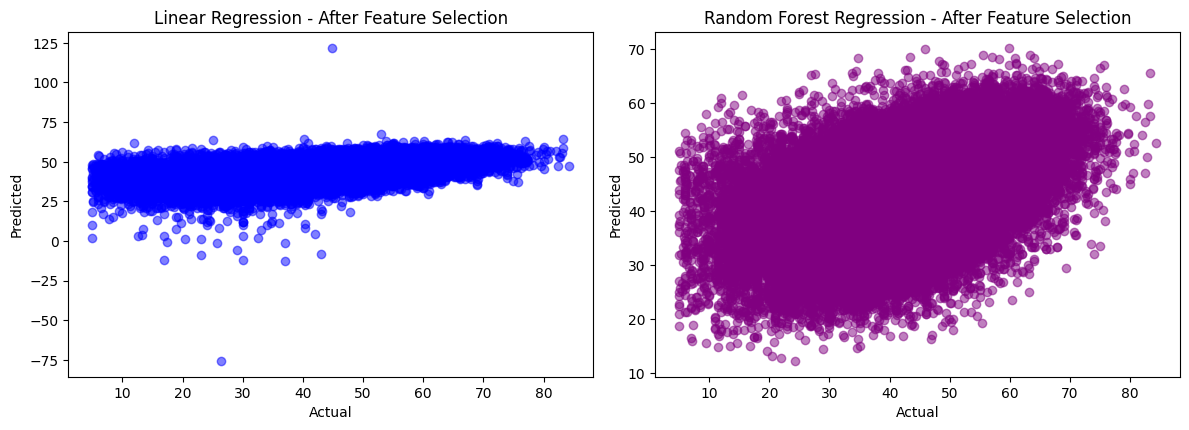

After Feature Selection:
Linear Regression - MSE: 86.8223890024766 R2: 0.29159900772447733
Random Forest - MSE: 100.22614746391419 R2: 0.1822350993663121


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

# Random Forest Regressor Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.5)
plt.title('Linear Regression - After Feature Selection')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(2, 2, 2)
plt.scatter(y_test, y_pred_rf, color='purple', alpha=0.5)
plt.title('Random Forest Regression - After Feature Selection')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

print("After Feature Selection:")
print("Linear Regression - MSE:", lr_mse, "R2:", lr_r2)
print("Random Forest - MSE:", rf_mse, "R2:", rf_r2)
